<a href="https://colab.research.google.com/github/wardla2/Epidemiology/blob/main/New_Mexico_Infant_Mortality_%26_Food_Insecurity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**New Mexico Infant Mortality & Food Insecurity Analysis**

Install libraries

In [ ]:
# Run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import geopandas as gpd          # for mapping in Python
import plotly.express as px       # optional: interactive charts

# Install geopandas if not available
# !pip install geopandas


Data Cleaning

In [ ]:
im = pd.read_csv('nm_infant_mortality_cdc_wonder.xls')

# Find where the data ends — WONDER footers usually start with "---" or "Notes"
# Check how many rows of actual data you have first:
print(im.head(20))
print("...")
print(im.tail(10))  # look for where the footer begins

                                                   Notes\t"County"\t"County Code"\tDeaths\tBirths\tDeath Rate
\t"Bernalillo County                                                   NM"\t"35001"\t244\t47270\t5.16        
\t"Unidentified Counties                                              NM"\t"35999"\t593\t108355\t5.47        
Total\t\t\t837\t155625\t5.38                                                                      NaN        
---                                                                                               NaN        
Dataset: Linked Birth / Infant Death Records, 2...                                                NaN        
Query Parameters:                                                                                 NaN        
States: New Mexico (35)                                                                           NaN        
Group By: County                                                                                  NaN        
Show Total

In [ ]:
# Read the file as a tab-separated values (TSV) file.
# The first row appears to be the header.
im = pd.read_csv('nm_infant_mortality_cdc_wonder.xls', sep='\t')

# The column names might have quotes and extra spaces, let's clean them.
im.columns = [col.strip().replace('"', '') for col in im.columns]

# The first column might be 'Notes' and is often empty for data rows, or contains metadata.
# Drop it if it exists and appears to be a descriptive/empty column.
if 'Notes' in im.columns and (im['Notes'].nunique(dropna=True) <= 1 or im['Notes'].isnull().all()):
    im = im.drop(columns=['Notes'])
# Alternatively, if there's an unnamed column (from an initial tab), drop it.
# This check ensures that if a leading tab caused an empty column name, it's removed.
if '' in im.columns: # Check if an empty string column name exists
    im = im.drop(columns=[''])

# Clean up 'County' column to remove ' NM' and leading/trailing spaces
im['County'] = im['County'].str.replace(' NM', '', regex=False).str.strip()

# Remove WONDER footer rows, typically starting with '---' or containing 'Total'
# The 'Total' row is a summary row.
im = im[~im['County'].str.contains('Total', na=False, regex=False)]

# Drop rows where 'County Code' is NaN after conversion to numeric
# This handles the original intention of the "Option 2" comment.
im['County Code'] = pd.to_numeric(im['County Code'], errors='coerce')
im = im[im['County Code'].notna()]
im['County Code'] = im['County Code'].astype(int).astype(str) # Convert to int then str for FIPS codes.

# Reset index after dropping rows to ensure a clean DataFrame index
im = im.reset_index(drop=True)

In [ ]:
# Display basic information about the DataFrame after cleaning
print("\n--- DataFrame Info after Cleaning ---")
im.info()

# Check for missing values in the cleaned DataFrame
print("\n--- Missing Values after Cleaning ---")
print(im.isnull().sum())

# Display descriptive statistics for numeric columns
print("\n--- Descriptive Statistics after Cleaning ---")
print(im.describe())


--- DataFrame Info after Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Notes        0 non-null      object 
 1   County       2 non-null      object 
 2   County Code  2 non-null      object 
 3   Deaths       2 non-null      float64
 4   Births       2 non-null      float64
 5   Death Rate   2 non-null      float64
dtypes: float64(3), object(3)
memory usage: 228.0+ bytes

--- Missing Values after Cleaning ---
Notes          2
County         0
County Code    0
Deaths         0
Births         0
Death Rate     0
dtype: int64

--- Descriptive Statistics after Cleaning ---
           Deaths         Births  Death Rate
count    2.000000       2.000000    2.000000
mean   418.500000   77812.500000    5.315000
std    246.780267   43193.617729    0.219203
min    244.000000   47270.000000    5.160000
25%    331.250000   62541.250000    5.2375

In [ ]:
display(im.head())

,Notes,County,County Code,Deaths,Births,Death Rate
0,NaN,"Bernalillo County,",35001,244.0,47270.0,5.16
1,NaN,"Unidentified Counties,",35999,593.0,108355.0,5.47


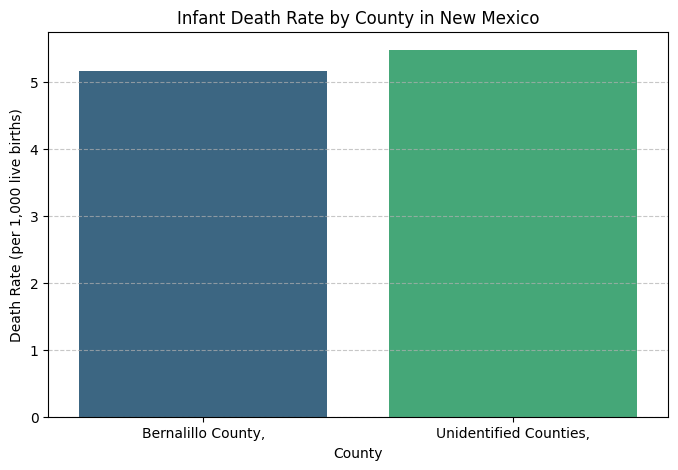

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize 'Death Rate' by 'County'
plt.figure(figsize=(8, 5))
# Corrected: Assign 'County' to hue and set legend=False to address the FutureWarning
sns.barplot(x='County', y='Death Rate', data=im, palette='viridis', hue='County', legend=False)
plt.title('Infant Death Rate by County in New Mexico')
plt.xlabel('County')
plt.ylabel('Death Rate (per 1,000 live births)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ---- 1. Load CDC WONDER infant mortality ----
im = pd.read_csv('nm_infant_mortality_cdc_wonder.xls', sep='\t')

# Clean column names
im.columns = [col.strip().replace('"', '') for col in im.columns]

# Drop Notes and unnamed columns
if 'Notes' in im.columns and (im['Notes'].nunique(dropna=True) <= 1 or im['Notes'].isnull().all()):
    im = im.drop(columns=['Notes'])
if '' in im.columns:
    im = im.drop(columns=[''])

# Clean County column
im['County'] = im['County'].str.replace(' NM', '', regex=False).str.strip()

# Remove Total row but KEEP Unidentified Counties for imputation
im = im[~im['County'].str.contains('Total', na=False, regex=False)]

# Convert Death Rate to numeric now so we can extract the unidentified rate
im['Death Rate'] = pd.to_numeric(im['Death Rate'], errors='coerce')

# Extract the Unidentified Counties aggregate rate before removing that row
unidentified_rate = im.loc[
    im['County'].str.contains('Unidentified', na=False, case=False),
    'Death Rate'
].values

if len(unidentified_rate) > 0:
    unidentified_rate = unidentified_rate[0]
    print(f"Unidentified Counties infant mortality rate: {unidentified_rate}")
else:
    raise ValueError("Could not find 'Unidentified Counties' row — check the source file.")

# Remove the Unidentified Counties row now that we have the rate
im = im[~im['County'].str.contains('Unidentified', na=False, case=False)]

# Convert County Code to FIPS — this will only retain Bernalillo at this point
im['County Code'] = pd.to_numeric(im['County Code'], errors='coerce')
im = im[im['County Code'].notna()]
im['fips'] = im['County Code'].astype(int).astype(str).str.zfill(5)

# Rename columns
im = im.rename(columns={
    'County': 'county_name',
    'Deaths': 'infant_deaths',
    'Births': 'live_births',
    'Death Rate': 'infant_mortality_rate'
})
im['imputed'] = False
im = im.reset_index(drop=True)

# ---- 2. Load County Health Rankings ----
path = '2025 County Health Rankings New Mexico Data - v3.xlsx'

select = pd.read_excel(path, sheet_name='Select Measure Data', skiprows=1)
select_nm = select[select['State'] == 'New Mexico'].copy()
select_nm = select_nm[['FIPS', 'County', 'Food Environment Index']]

additional = pd.read_excel(path, sheet_name='Additional Measure Data', skiprows=1)
additional_nm = additional[additional['State'] == 'New Mexico'].copy()
additional_nm = additional_nm[['FIPS', 'Median Household Income',
                                '% Food Insecure', '% Limited Access to Healthy Foods']]

chr_nm = select_nm.merge(additional_nm, on='FIPS', how='left')
chr_nm['fips'] = chr_nm['FIPS'].astype(str).str.zfill(5)
chr_nm = chr_nm.drop(columns='FIPS')

# ---- 3. Load Feeding America (2023 data only) ----
fa = pd.read_excel('MMG2025_2019-2023_Data_To_Share.xlsx', sheet_name='County', skiprows=0)

# Filter for New Mexico (state abbreviation 'NM', not 'New Mexico')
# and keep only the most recent year (2023)
fa_nm = fa[(fa['State'] == 'NM') & (fa['Year'] == 2023)].copy()
fa_nm['fips'] = fa_nm['FIPS'].astype(str).str.zfill(5)
fa_nm = fa_nm[['fips', 'Overall Food Insecurity Rate', 'Child Food Insecurity Rate']]

print(f"Feeding America rows after filter: {len(fa_nm)}")  # should be 33
print(fa_nm.head())

# ---- 4. Merge all on FIPS ----
# Force chr_nm fips to zero-padded string as well (it's currently an integer)
chr_nm['fips'] = chr_nm['fips'].astype(str).str.zfill(5)

df = chr_nm.merge(im[['fips', 'infant_mortality_rate', 'infant_deaths',
                       'live_births', 'imputed']], on='fips', how='left')
df = df.merge(fa_nm, on='fips', how='left')

# Drop the state-level summary row (FIPS 35000 = New Mexico state, not a county)
df = df[df['fips'] != '35000']

# ---- 5. Impute infant mortality for non-Bernalillo counties ----
bernalillo_fips = '35001'
mask = (df['fips'] != bernalillo_fips) & (df['infant_mortality_rate'].isna())
df.loc[mask, 'infant_mortality_rate'] = unidentified_rate
df.loc[mask, 'imputed'] = True
df['imputed'] = df['imputed'].fillna(False)

print(f"Counties with observed rate: {(df['imputed'] == False).sum()}")
print(f"Counties with imputed rate:  {df['imputed'].sum()}")
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.to_csv('nm_merged_analysis.csv', index=False)

Unidentified Counties infant mortality rate: 5.47
Feeding America rows after filter: 33
       fips  Overall Food Insecurity Rate  Child Food Insecurity Rate
8985  35001                         0.152                       0.199
8990  35003                         0.213                       0.376
8995  35005                         0.182                       0.240
9000  35006                         0.206                       0.331
9005  35007                         0.172                       0.269
Counties with observed rate: 1
Counties with imputed rate:  32

Shape: (33, 12)

Missing values:
 County                                0
Food Environment Index                0
Median Household Income               0
% Food Insecure                       0
% Limited Access to Healthy Foods     0
fips                                  0
infant_mortality_rate                 0
infant_deaths                        32
live_births                          32
imputed                           

/tmp/ipykernel_1184/1097693463.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['imputed'] = df['imputed'].fillna(False)


In [ ]:
# Fix FIPS formatting before saving
df['fips'] = df['fips'].astype(str).str.replace('.0', '', regex=False).str.zfill(5)
df.to_csv('nm_merged_analysis.csv', index=False)

In [ ]:
df = df.drop(columns=['infant_deaths', 'live_births'])

print(df.columns.tolist())
print(df.shape)
df.to_csv('nm_merged_analysis.csv', index=False)

['County', 'Food Environment Index', 'Median Household Income', '% Food Insecure', '% Limited Access to Healthy Foods', 'fips', 'infant_mortality_rate', 'imputed', 'Overall Food Insecurity Rate', 'Child Food Insecurity Rate']
(33, 10)


In [ ]:
# Add clean county name and state columns for Tableau geographic matching
df['tableau_county'] = df['County'].str.replace(' County', '', regex=False).str.strip()
df['tableau_state'] = 'New Mexico'

df.to_csv('nm_merged_analysis.csv', index=False)

Descriptive Statistics

In [ ]:
# Summary statistics — all key variables
print(df[['infant_mortality_rate',
          'Food Environment Index',
          'Median Household Income',
          '% Food Insecure',
          '% Limited Access to Healthy Foods',
          'Overall Food Insecurity Rate',
          'Child Food Insecurity Rate']].describe().round(3))

       infant_mortality_rate  Food Environment Index  Median Household Income  \
count                 33.000                  33.000                   33.000   
mean                   5.461                   5.976                55072.182   
std                    0.054                   1.756                19158.051   
min                    5.160                   1.000                38641.000   
25%                    5.470                   5.300                45685.000   
50%                    5.470                   6.300                51111.000   
75%                    5.470                   7.100                56785.000   
max                    5.470                   9.300               146208.000   

       % Food Insecure  % Limited Access to Healthy Foods  \
count           33.000                             33.000   
mean            16.397                             18.520   
std              3.121                             12.692   
min              7.500    

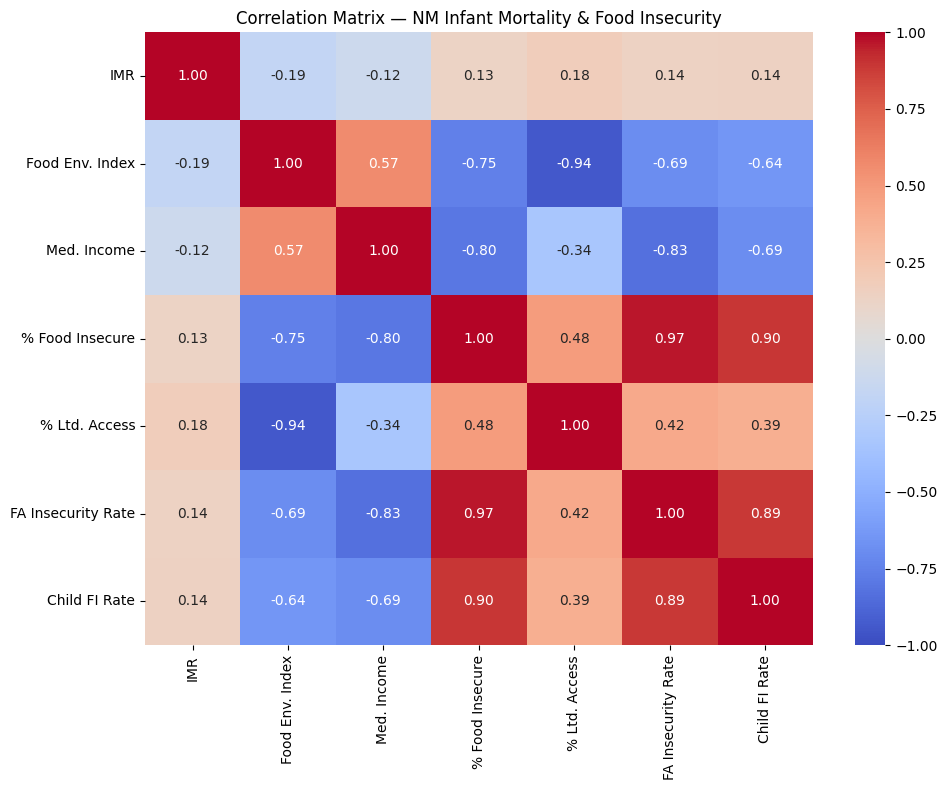

In [ ]:
# Correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ['infant_mortality_rate',
             'Food Environment Index',
             'Median Household Income',
             '% Food Insecure',
             '% Limited Access to Healthy Foods',
             'Overall Food Insecurity Rate',
             'Child Food Insecurity Rate']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            xticklabels=['IMR', 'Food Env. Index', 'Med. Income',
                         '% Food Insecure', '% Ltd. Access',
                         'FA Insecurity Rate', 'Child FI Rate'],
            yticklabels=['IMR', 'Food Env. Index', 'Med. Income',
                         '% Food Insecure', '% Ltd. Access',
                         'FA Insecurity Rate', 'Child FI Rate'])
plt.title('Correlation Matrix — NM Infant Mortality & Food Insecurity')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Spearman correlations with infant mortality rate for each food/income variable
from scipy.stats import spearmanr

predictors = ['Food Environment Index',
              'Median Household Income',
              '% Food Insecure',
              '% Limited Access to Healthy Foods',
              'Overall Food Insecurity Rate',
              'Child Food Insecurity Rate']

print(f"{'Variable':<40} {'Spearman r':>12} {'p-value':>10}")
print("-" * 64)
for col in predictors:
    clean = df[['infant_mortality_rate', col]].dropna()
    r, p = spearmanr(clean['infant_mortality_rate'], clean[col])
    sig = '*' if p < 0.05 else ''
    print(f"{col:<40} {r:>12.3f} {p:>10.4f} {sig}")

Variable                                   Spearman r    p-value
----------------------------------------------------------------
Food Environment Index                         -0.242     0.1757 
Median Household Income                        -0.241     0.1760 
% Food Insecure                                 0.204     0.2541 
% Limited Access to Healthy Foods               0.260     0.1441 
Overall Food Insecurity Rate                    0.223     0.2125 
Child Food Insecurity Rate                      0.186     0.3008 


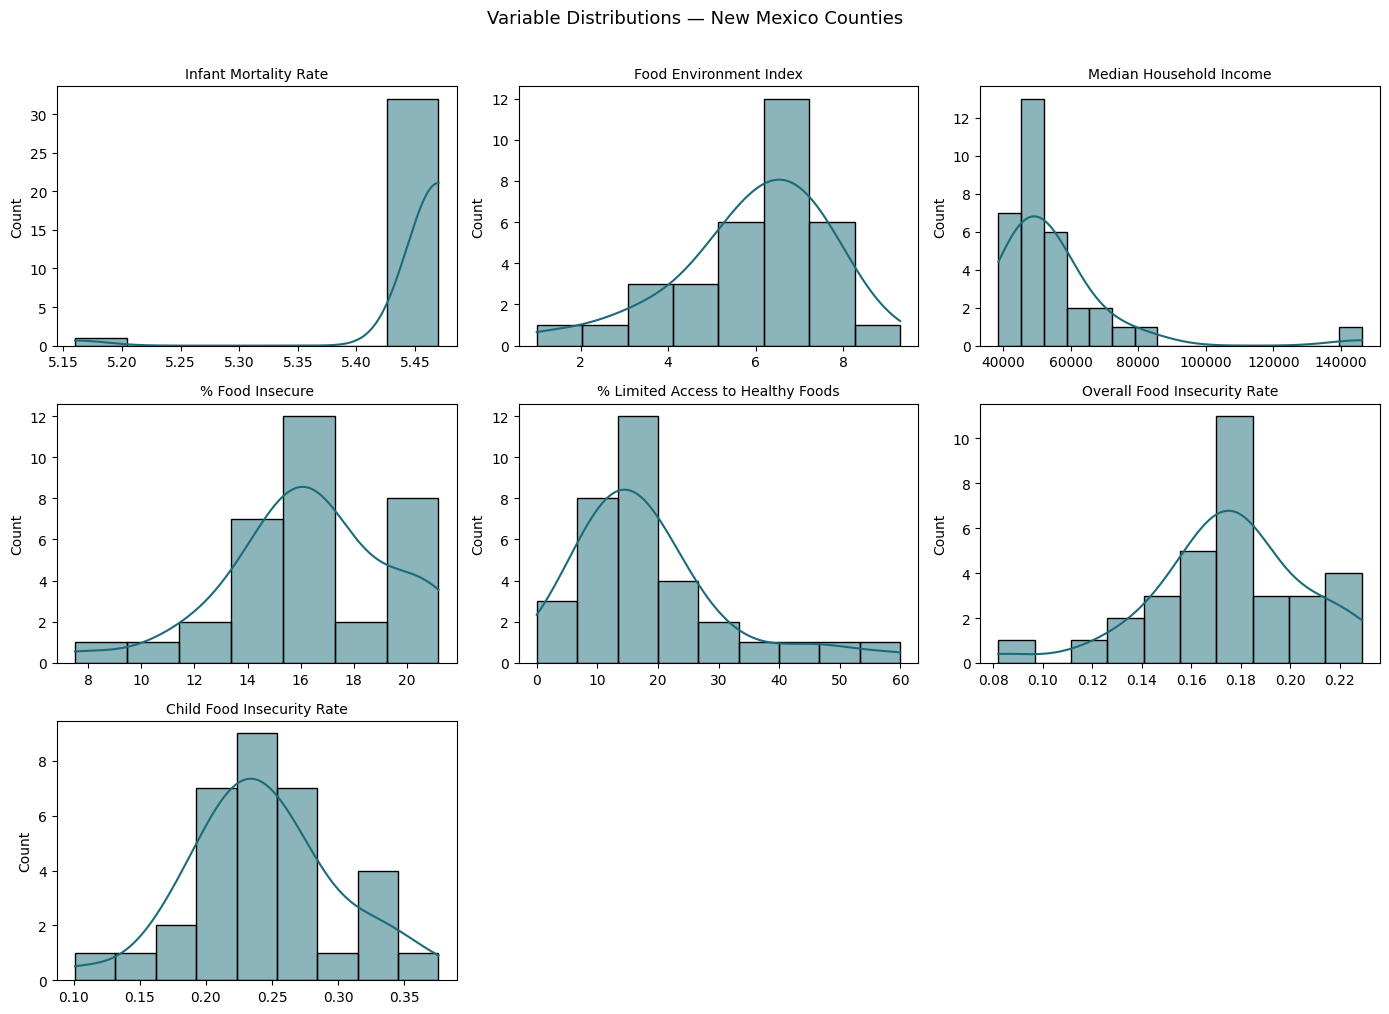

In [ ]:
# Histograms for all variables
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

plot_vars = ['infant_mortality_rate',
             'Food Environment Index',
             'Median Household Income',
             '% Food Insecure',
             '% Limited Access to Healthy Foods',
             'Overall Food Insecurity Rate',
             'Child Food Insecurity Rate']

labels = ['Infant Mortality Rate', 'Food Environment Index',
          'Median Household Income', '% Food Insecure',
          '% Limited Access to Healthy Foods',
          'Overall Food Insecurity Rate', 'Child Food Insecurity Rate']

for i, (col, label) in enumerate(zip(plot_vars, labels)):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#1B6B78')
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variable Distributions — New Mexico Counties', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('histograms_all_vars.png', dpi=150, bbox_inches='tight')
plt.show()

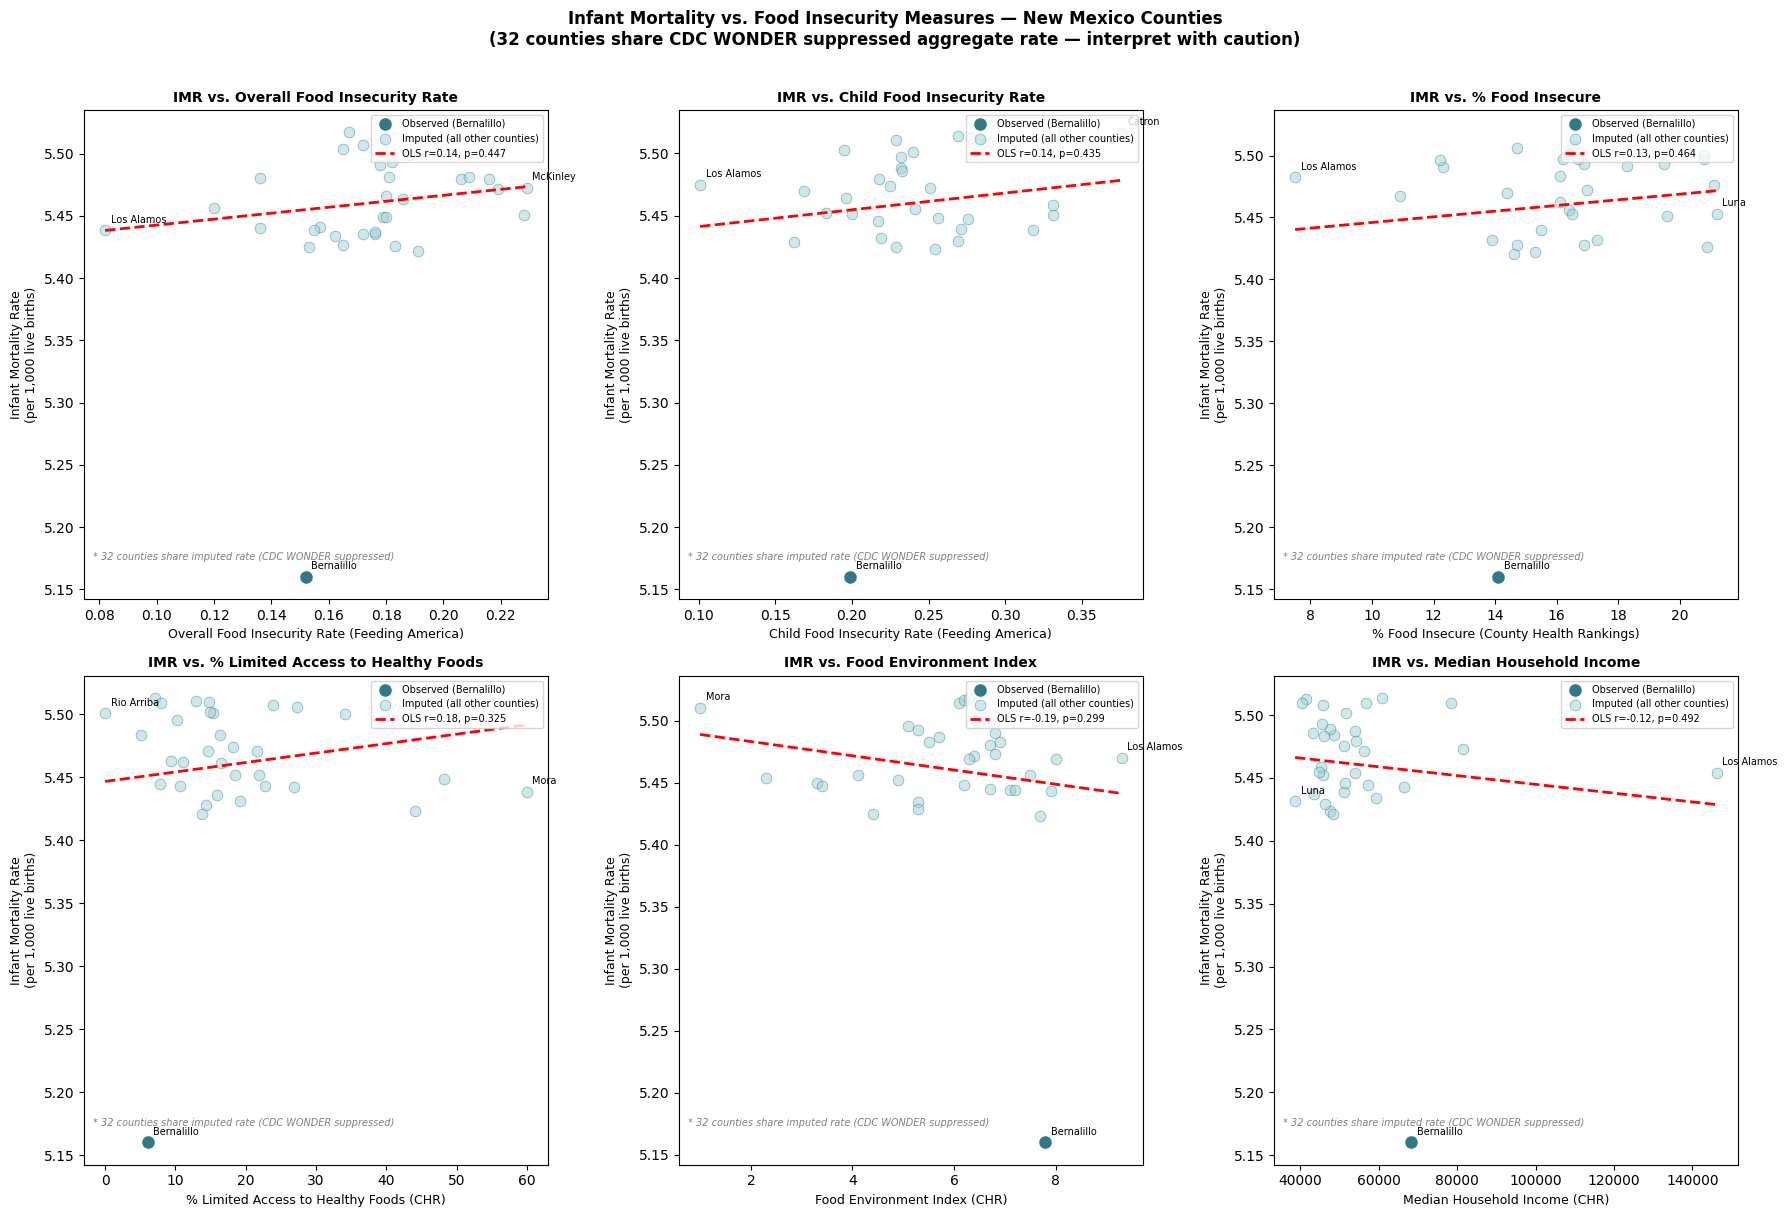

In [ ]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

predictors = {
    'Overall Food Insecurity Rate':       'Overall Food Insecurity Rate (Feeding America)',
    'Child Food Insecurity Rate':         'Child Food Insecurity Rate (Feeding America)',
    '% Food Insecure':                    '% Food Insecure (County Health Rankings)',
    '% Limited Access to Healthy Foods':  '% Limited Access to Healthy Foods (CHR)',
    'Food Environment Index':             'Food Environment Index (CHR)',
    'Median Household Income':            'Median Household Income (CHR)',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

np.random.seed(42)

for i, (col, xlabel) in enumerate(predictors.items()):
    ax = axes[i]
    clean = df.dropna(subset=[col, 'infant_mortality_rate']).reset_index(drop=True)

    # Add small y-axis jitter to imputed counties only
    jitter = np.where(clean['imputed'], np.random.uniform(-0.05, 0.05, len(clean)), 0)
    y_plot = clean['infant_mortality_rate'].values + jitter

    # Plot imputed and observed with different colors
    imputed_mask = clean['imputed'] == True
    ax.scatter(clean.loc[~imputed_mask, col], y_plot[~imputed_mask],
               color='#1B6B78', s=100, alpha=0.9, edgecolors='white',
               zorder=3, label='Observed (Bernalillo)')
    ax.scatter(clean.loc[imputed_mask, col], y_plot[imputed_mask],
               color='#A0CFD6', s=60, alpha=0.5, edgecolors='#1B6B78',
               linewidths=0.5, zorder=2, label='Imputed (all other counties)')

    # Label only Bernalillo and x-axis min/max outliers
    x_min_idx = clean[col].idxmin()
    x_max_idx = clean[col].idxmax()
    observed_idx = clean[~imputed_mask].index.tolist()
    label_indices = set(observed_idx + [x_min_idx, x_max_idx])

    for idx in label_indices:
        row = clean.loc[idx]
        name = str(row['County']).replace(' County', '').replace(', NM', '')
        ax.annotate(name,
                    (row[col], y_plot[idx]),  # idx is now a positional integer
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

    # OLS trendline
    m, b, r, p, se = linregress(clean[col], clean['infant_mortality_rate'])
    x_line = np.linspace(clean[col].min(), clean[col].max(), 100)
    ax.plot(x_line, m * x_line + b, 'r--', lw=2,
            label=f'OLS r={r:.2f}, p={p:.3f}')

    ax.text(0.02, 0.08,
            '* 32 counties share imputed rate (CDC WONDER suppressed)',
            transform=ax.transAxes, fontsize=7, color='gray', style='italic')

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Infant Mortality Rate\n(per 1,000 live births)', fontsize=9)
    ax.set_title(f'IMR vs. {col}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Infant Mortality vs. Food Insecurity Measures — New Mexico Counties\n'
             '(32 counties share CDC WONDER suppressed aggregate rate — interpret with caution)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_all_predictors.png', dpi=150, bbox_inches='tight')
plt.show()